In [1]:
"""
============================================================
 03_model_evaluation_and_comparison.py
 Smart Waste Detection — Post‑Training Analysis
============================================================
Load experiment results, build visual leaderboard, evaluate the
best model on the test set, show confusion matrix, per‑class
metrics, misclassifications, and Grad‑CAM explainability.
"""

'\n============================================================\n 03_model_evaluation_and_comparison.py\n Smart Waste Detection — Post‑Training Analysis\n============================================================\nLoad experiment results, build visual leaderboard, evaluate the\nbest model on the test set, show confusion matrix, per‑class\nmetrics, misclassifications, and Grad‑CAM explainability.\n'

# 📊 03 — Model Evaluation & Comparison
Comprehensive post‑training analysis of all experiments.

In [2]:
import sys, os
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()
sys.path.insert(0, current_dir)

import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from config import PATHS, CLASS_NAMES, NUM_CLASSES
from utils.dataset_utils import (
    set_seed, get_device, create_data_transforms, build_dataloaders,
)
from utils.training_utils import create_model, load_checkpoint
from utils.inference_utils import (
    evaluate_model, plot_confusion_matrix, plot_training_curves,
    show_misclassifications, visualize_gradcam, get_target_layer,
)

set_seed(42)
device = get_device()

c:\SDIS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Random seed set to 42
[INFO] Using CPU


## 1. Load Experiment Results

In [3]:
lb_path = PATHS["outputs"] / "experiment_leaderboard.csv"
if lb_path.exists():
    df = pd.read_csv(lb_path, index_col=0)
    print("=" * 70)
    print("               EXPERIMENT LEADERBOARD")
    print("=" * 70)
    print(df.to_string())
    print("=" * 70)
else:
    print("[WARN] No leaderboard found. Run 02_model_training first.")

               EXPERIMENT LEADERBOARD
         Model Optimizer      LR  Best Val Acc%  Time (min)  Params (M)
Rank                                                                   
1     resnet18     adamw  0.0003          94.49       530.2        11.2


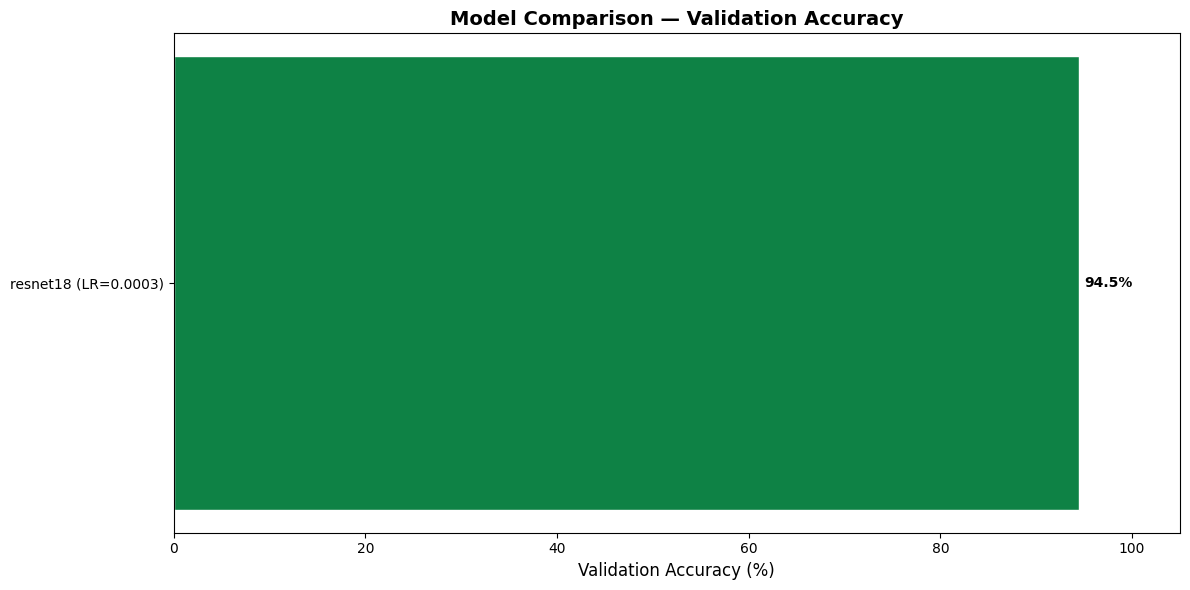

In [4]:
if lb_path.exists():
    fig, ax = plt.subplots(figsize=(12, 6))
    models = df["Model"].astype(str) + " (LR=" + df["LR"].astype(str) + ")"
    acc = df["Best Val Acc%"]
    colors = plt.cm.RdYlGn(acc / 100)

    bars = ax.barh(models, acc, color=colors, edgecolor="white")
    ax.set_xlabel("Validation Accuracy (%)", fontsize=12)
    ax.set_title("Model Comparison — Validation Accuracy", fontsize=14, fontweight="bold")
    ax.set_xlim(0, 105)

    for bar, a in zip(bars, acc):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{a:.1f}%", va="center", fontweight="bold", fontsize=10)

    plt.tight_layout()
    fig.savefig(str(PATHS["outputs"] / "model_comparison.png"), dpi=150, bbox_inches="tight")
    plt.show()

## 2. Load Best Model

In [5]:
best_info_path = PATHS["outputs"] / "best_model_info.json"
if best_info_path.exists():
    with open(best_info_path) as f:
        best_info = json.load(f)
    print(f"\n🏆 Best model : {best_info['model_tag']}")
    print(f"   Val Acc    : {best_info['best_val_acc']:.2f}%")
else:
    print("[WARN] No best_model_info.json found.")
    best_info = {"model_tag": "resnet18_lr0.0001_adamw", "best_val_acc": 0}

# Parse model name from tag
model_tag = best_info["model_tag"]
model_backbone = model_tag.split("_lr")[0]  # e.g. "resnet18"
print(f"   Backbone   : {model_backbone}")


🏆 Best model : resnet18_lr0.0003_adamw
   Val Acc    : 94.49%
   Backbone   : resnet18


In [6]:
model = create_model(model_backbone, NUM_CLASSES, pretrained=False).to(device)

best_ckpt = PATHS["best_model"]
if best_ckpt.exists():
    ckpt = torch.load(best_ckpt, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"[INFO] Loaded model from {best_ckpt}")
else:
    # Try phase2 checkpoint
    phase2_path = PATHS["models"] / f"{model_tag}_phase2_best.pth"
    if phase2_path.exists():
        load_checkpoint(model, str(phase2_path), device)
    else:
        print("[ERROR] No checkpoint found. Cannot evaluate.")

model.eval()

[INFO] Created resnet18 via timm (pretrained=False)
[INFO] Loaded model from c:\SDIS\models\best_waste_classifier.pth


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act1): ReLU(inplace=True)
      (aa): Identity()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act2): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, m

## 3. Test Set Evaluation

In [7]:
transforms_dict = create_data_transforms(224, augment="none")
loaders, dsets = build_dataloaders(
    PATHS["dataset"], transforms_dict,
    batch_size=32, num_workers=2,
)

test_loader = loaders.get("test")
if test_loader is None:
    print("[ERROR] No test set found!")
else:
    print(f"\nTest set: {len(dsets['test'])} images")

[INFO] train → 8,578 images, 268 batches
[INFO] val   → 1,833 images, 58 batches
[INFO] test  → 1,848 images, 58 batches

Test set: 1848 images


In [8]:
if test_loader:
    preds, labels, probs, metrics = evaluate_model(
        model, test_loader, device, CLASS_NAMES
    )

    print(f"\n{'='*50}")
    print(f"  TEST SET RESULTS")
    print(f"{'='*50}")
    print(f"  Accuracy  : {metrics['accuracy']:.2f}%")
    print(f"  Precision : {metrics['precision']:.4f}")
    print(f"  Recall    : {metrics['recall']:.4f}")
    print(f"  F1 Score  : {metrics['f1_score']:.4f}")
    print(f"{'='*50}")

    # Save metrics
    with open(PATHS["outputs"] / "test_metrics.json", "w") as f:
        json.dump({k: v for k, v in metrics.items()
                   if k != "classification_report"}, f, indent=2)

Evaluating:   0%|          | 0/58 [00:00<?, ?it/s]c:\SDIS\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Evaluating: 100%|██████████| 58/58 [01:36<00:00,  1.66s/it]

              precision    recall  f1-score   support

     battery       0.96      0.96      0.96       114
  biological       0.96      0.98      0.97       106
   cardboard       0.96      0.93      0.95       213
     clothes       1.00      0.99      0.99       285
       glass       0.94      0.91      0.93       261
       metal       0.87      0.93      0.90       140
       paper       0.91      0.94      0.92       201
     plastic       0.96      0.90      0.93       241
       shoes       0.96      0.98      0.97       218
       trash       0.81      0.90      0.85        69

    accuracy                           0.94      1848
   macro avg       0.93      0.94      0.94      1848
weighted avg       0.94      0.94      0.94      1848


[RESULT] Accuracy: 94.37%  |  F1: 0.9440

  TEST SET RESULTS
  Accuracy  : 94.37%
  Precision : 0.9450
  Recall    : 0.9437
  F1 Score  : 0.9440


## 4. Confusion Matrix

[INFO] Confusion matrix saved → c:\SDIS\outputs\confusion_matrix_normalized.png


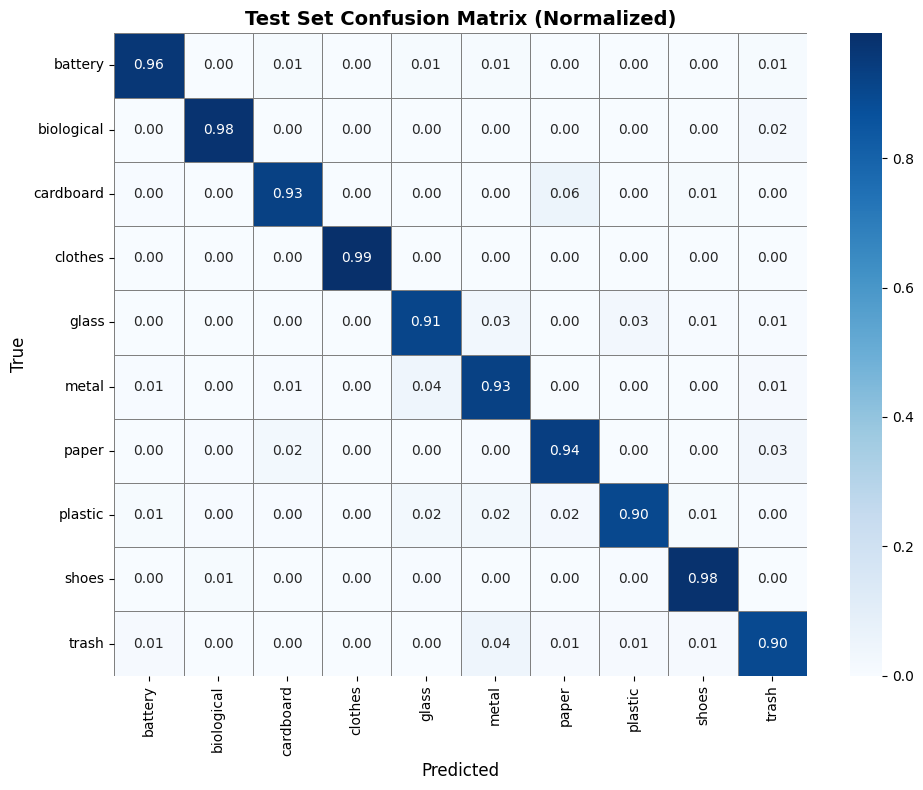

[INFO] Confusion matrix saved → c:\SDIS\outputs\confusion_matrix_counts.png


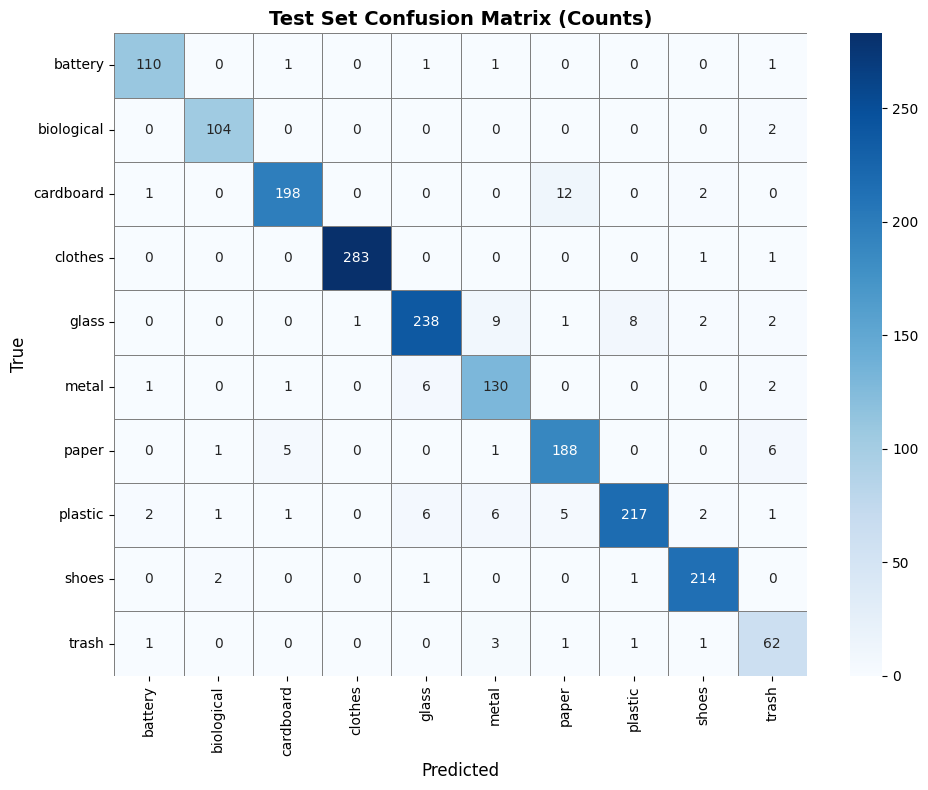

In [9]:
if test_loader:
    plot_confusion_matrix(
        labels, preds, CLASS_NAMES,
        title="Test Set Confusion Matrix",
        save_path=str(PATHS["outputs"] / "confusion_matrix_normalized.png"),
        normalize=True,
    )
    plot_confusion_matrix(
        labels, preds, CLASS_NAMES,
        title="Test Set Confusion Matrix (Counts)",
        save_path=str(PATHS["outputs"] / "confusion_matrix_counts.png"),
        normalize=False,
    )

## 5. Per‑Class Analysis

In [10]:
if test_loader:
    from sklearn.metrics import classification_report
    report_dict = classification_report(labels, preds, target_names=CLASS_NAMES,
                                         output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report_dict).T
    print("\nPer-Class Metrics:")
    print(df_report.to_string())
    df_report.to_csv(PATHS["outputs"] / "per_class_metrics.csv")


Per-Class Metrics:
              precision    recall  f1-score      support
battery        0.956522  0.964912  0.960699   114.000000
biological     0.962963  0.981132  0.971963   106.000000
cardboard      0.961165  0.929577  0.945107   213.000000
clothes        0.996479  0.992982  0.994728   285.000000
glass          0.944444  0.911877  0.927875   261.000000
metal          0.866667  0.928571  0.896552   140.000000
paper          0.908213  0.935323  0.921569   201.000000
plastic        0.955947  0.900415  0.927350   241.000000
shoes          0.963964  0.981651  0.972727   218.000000
trash          0.805195  0.898551  0.849315    69.000000
accuracy       0.943723  0.943723  0.943723     0.943723
macro avg      0.932156  0.942499  0.936788  1848.000000
weighted avg   0.944974  0.943723  0.943955  1848.000000


## 6. Misclassified Examples

[INFO] Misclassification gallery saved → c:\SDIS\outputs\misclassifications.png


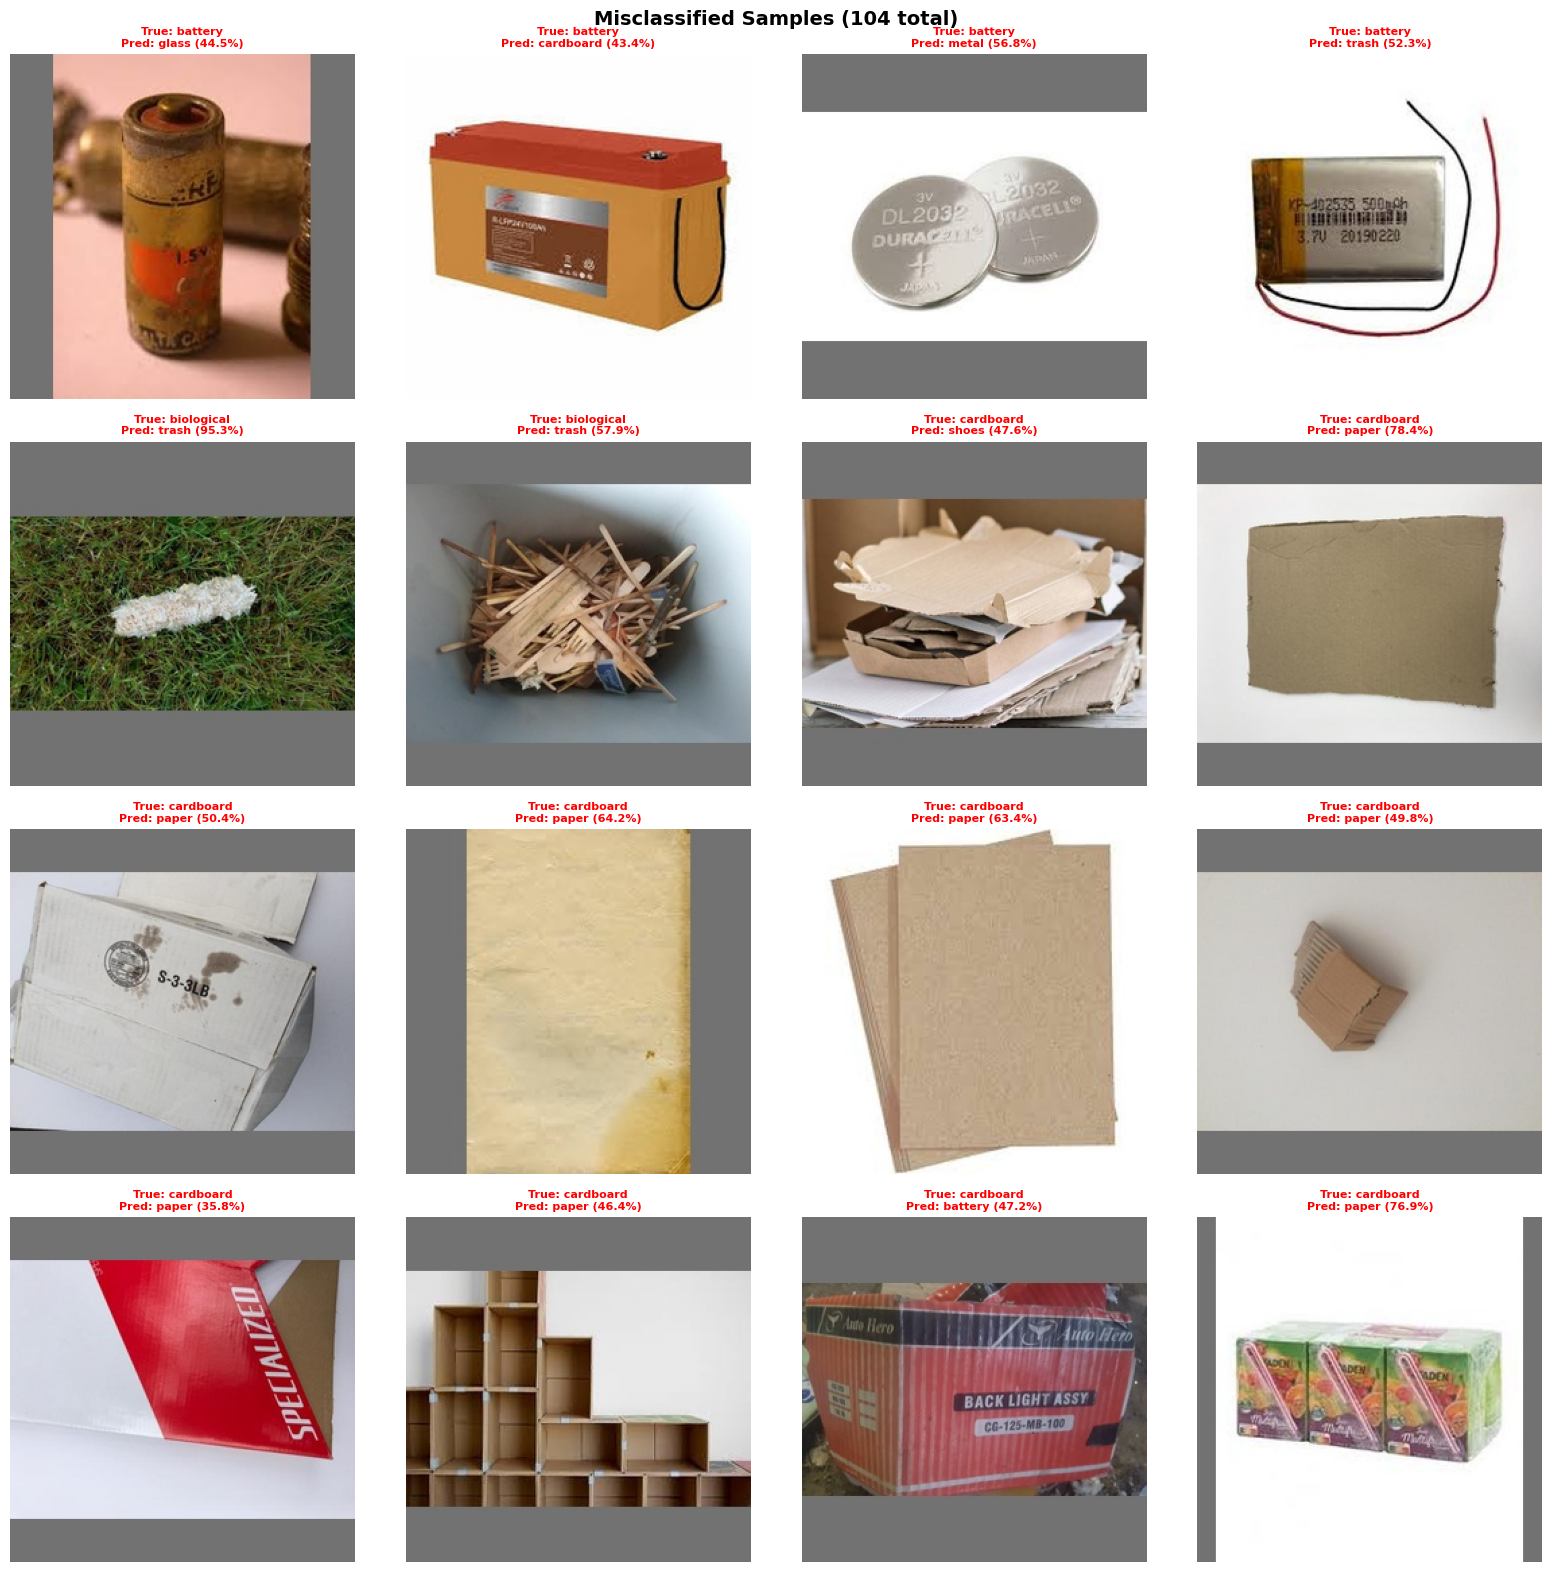

In [11]:
if test_loader and "test" in dsets:
    show_misclassifications(
        model, dsets["test"], device, CLASS_NAMES,
        num_show=16,
        save_path=str(PATHS["outputs"] / "misclassifications.png"),
    )

## 7. Training Curve Comparison

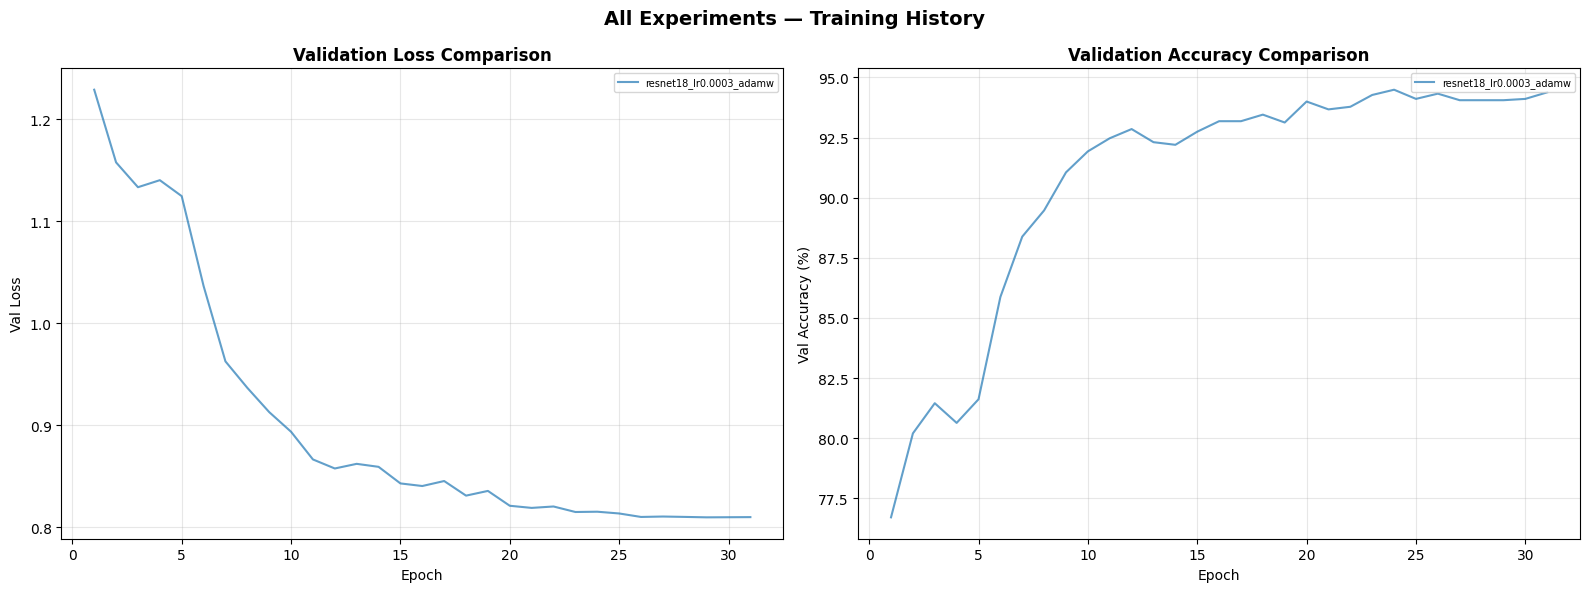

In [12]:
log_files = list(PATHS["logs"].glob("history_*.json"))
if log_files:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for log_file in log_files:
        with open(log_file) as f:
            hist = json.load(f)
        label = log_file.stem.replace("history_", "")
        epochs = range(1, len(hist["val_acc"]) + 1)
        ax1.plot(epochs, hist["val_loss"], label=label, alpha=0.7, linewidth=1.5)
        ax2.plot(epochs, hist["val_acc"], label=label, alpha=0.7, linewidth=1.5)

    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Val Loss")
    ax1.set_title("Validation Loss Comparison", fontweight="bold")
    ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3)

    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val Accuracy (%)")
    ax2.set_title("Validation Accuracy Comparison", fontweight="bold")
    ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

    fig.suptitle("All Experiments — Training History", fontsize=14, fontweight="bold")
    plt.tight_layout()
    fig.savefig(str(PATHS["outputs"] / "all_experiments_comparison.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

## 8. Grad‑CAM Explainability

In [13]:
if test_loader and "test" in dsets:
    test_dir = PATHS["dataset"] / "test"
    sample_images = []
    for cls_dir in sorted(test_dir.iterdir()):
        if cls_dir.is_dir():
            imgs = list(cls_dir.iterdir())
            if imgs:
                sample_images.append(str(imgs[0]))

    print(f"\nGenerating Grad‑CAM for {len(sample_images)} sample images...")
    for i, img_path in enumerate(sample_images[:5]):
        try:
            visualize_gradcam(
                model, model_backbone, img_path, CLASS_NAMES, device,
                image_size=224,
                save_path=str(PATHS["outputs"] / f"gradcam_sample_{i}.png"),
            )
        except Exception as e:
            print(f"[WARN] Grad‑CAM failed for {img_path}: {e}")


Generating Grad‑CAM for 10 sample images...
[WARN] Grad‑CAM failed for c:\SDIS\dataset_split\test\battery\battery_104.jpg: No module named 'cv2'
[WARN] Grad‑CAM failed for c:\SDIS\dataset_split\test\biological\biological_108.jpg: No module named 'cv2'
[WARN] Grad‑CAM failed for c:\SDIS\dataset_split\test\cardboard\cardboard_1009.jpg: No module named 'cv2'
[WARN] Grad‑CAM failed for c:\SDIS\dataset_split\test\clothes\clothes_1007.jpg: No module named 'cv2'
[WARN] Grad‑CAM failed for c:\SDIS\dataset_split\test\glass\glass_1.jpg: No module named 'cv2'


## 9. Final Recommendation

In [14]:
print("\n" + "=" * 60)
print("          EVALUATION SUMMARY")
print("=" * 60)
if test_loader:
    print(f"  Best Model     : {model_tag}")
    print(f"  Test Accuracy  : {metrics['accuracy']:.2f}%")
    print(f"  Test F1 Score  : {metrics['f1_score']:.4f}")
    print(f"  Model Path     : {PATHS['best_model']}")
print("=" * 60)
print("\n✅ Evaluation complete. Proceed to 04_smart_dustbin_simulation.py")


          EVALUATION SUMMARY
  Best Model     : resnet18_lr0.0003_adamw
  Test Accuracy  : 94.37%
  Test F1 Score  : 0.9440
  Model Path     : c:\SDIS\models\best_waste_classifier.pth

✅ Evaluation complete. Proceed to 04_smart_dustbin_simulation.py
